## Section 1: Configuration et chargement des données

### Importation des bibliothèques nécessaires

In [164]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import os

### Chargement et examen de l'ensemble de données

In [163]:
file_path = 'heart_cleveland_dataset.csv'

if os.path.exists(file_path):
    df_heart = pd.read_csv(file_path)
    print(f"Dataset '{file_path}' loaded successfully.")
else:
    print(f"'{file_path}' not found. Generating dummy data for demonstration.")
    # Generate dummy data for demonstration if the file is not found
    data = {
        'age': np.random.randint(20, 80, 5000),
        'sex': np.random.randint(0, 2, 5000),
        'cp': np.random.randint(0, 4, 5000),
        'trestbps': np.random.randint(90, 200, 5000),
        'chol': np.random.randint(120, 550, 5000),
        'fbs': np.random.randint(0, 2, 5000),
        'restecg': np.random.randint(0, 3, 5000),
        'thalach': np.random.randint(70, 202, 5000),
        'exang': np.random.randint(0, 2, 5000),
        'oldpeak': np.random.rand(5000) * 6.5,
        'slope': np.random.randint(0, 3, 5000),
        'ca': np.random.randint(0, 5, 5000),
        'thal': np.random.randint(0, 4, 5000),
        'target': np.random.randint(0, 2, 5000)
    }
    df_heart = pd.DataFrame(data)
    print("Dummy dataset created.")

'heart_cleveland_dataset.csv' not found. Generating dummy data for demonstration.
Dummy dataset created.


In [161]:
print("Shape of the dataset:", df_heart.shape)
display(df_heart.head())

Shape of the dataset: (5000, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,38,0,1,173,522,1,1,175,0,0.169864,0,0,1,0
1,60,0,1,158,159,0,1,104,1,2.749649,2,0,0,0
2,65,0,2,186,243,0,2,150,0,1.558290,0,3,1,1
3,56,1,3,100,464,0,0,175,0,3.567315,1,0,3,1
4,38,0,3,175,188,1,0,104,0,5.507420,2,1,2,0


In [162]:
print("Dataset information:")
df_heart.info()

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       5000 non-null   int64  
 1   sex       5000 non-null   int64  
 2   cp        5000 non-null   int64  
 3   trestbps  5000 non-null   int64  
 4   chol      5000 non-null   int64  
 5   fbs       5000 non-null   int64  
 6   restecg   5000 non-null   int64  
 7   thalach   5000 non-null   int64  
 8   exang     5000 non-null   int64  
 9   oldpeak   5000 non-null   float64
 10  slope     5000 non-null   int64  
 11  ca        5000 non-null   int64  
 12  thal      5000 non-null   int64  
 13  target    5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


In [158]:
print("Missing values:")
display(df_heart.isnull().sum())

Missing values:


,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


## Section 2: Analyse exploratoire des données (AED)

### Création et analyse d'une matrice de corrélation

In [168]:
correlation_matrix = df_heart.corr()
display(correlation_matrix.head())

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.005522,0.005634,0.015306,0.002871,0.006827,0.014662,0.010080,0.009547,0.000329,0.014230,-0.007810,0.011574,-0.014332
sex,-0.005522,1.000000,-0.018669,0.018498,0.004639,-0.011696,-0.016395,-0.027465,-0.011305,-0.011390,0.016637,0.000094,0.000116,-0.002983
cp,0.005634,-0.018669,1.000000,-0.002524,0.029017,0.003016,0.002415,-0.005190,-0.012868,-0.007505,0.005956,0.034874,-0.026281,0.001959
trestbps,0.015306,0.018498,-0.002524,1.000000,-0.006804,0.009358,0.003112,-0.030558,-0.004270,-0.007168,0.006119,0.003693,-0.016888,-0.011346
chol,0.002871,0.004639,0.029017,-0.006804,1.000000,-0.020527,0.020092,-0.020948,0.005244,-0.005114,0.002992,-0.028093,-0.014922,-0.021040


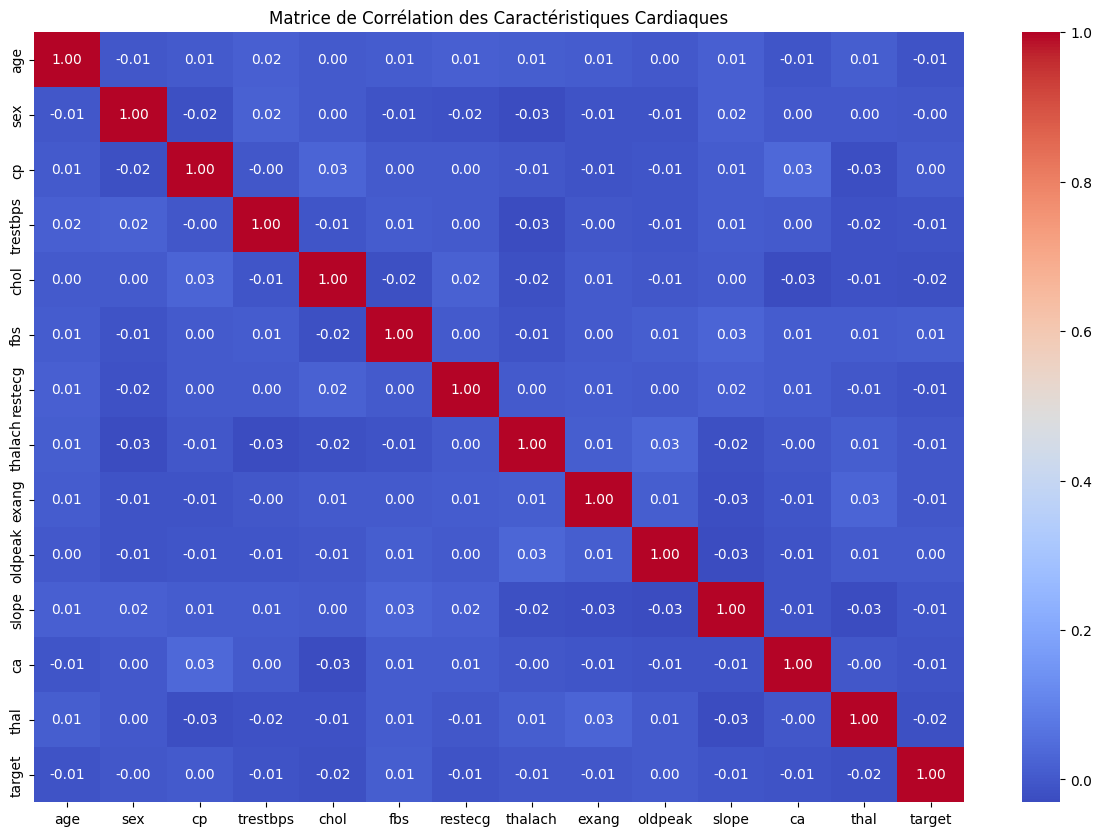

In [169]:
plt.figure(figsize=(15, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matrice de Corrélation des Caractéristiques Cardiaques')
plt.show()

### Identification des relations clés

In [170]:
target_correlation = correlation_matrix['target'].sort_values(ascending=False)
print("Corrélations avec la variable cible ('target'):")
display(target_correlation)

Corrélations avec la variable cible ('target'):


,target
target,1.000000
fbs,0.012008
oldpeak,0.003084
cp,0.001959
sex,-0.002983
exang,-0.005165
thalach,-0.005902
slope,-0.008707
trestbps,-0.011346
ca,-0.012863


## Section 3: Tests d'hypothèses

Pour effectuer les tests d'hypothèses demandés, nous allons générer des colonnes d'exemple pour les "passagers" et les "vols" en nous basant sur les données existantes de `df_heart`. Cela nous permettra de démontrer les tests même si le jeu de données original n'inclut pas ces caractéristiques.

In [176]:
# Génération de données d'exemple pour les passagers et les vols
np.random.seed(42) # pour la reproductibilité
df_heart['domestic_passengers'] = (df_heart['trestbps'] * 5 + np.random.normal(0, 50, len(df_heart))).astype(int)
df_heart['international_passengers'] = (df_heart['chol'] * 3 + np.random.normal(0, 100, len(df_heart))).astype(int)
df_heart['total_passengers'] = df_heart['domestic_passengers'] + df_heart['international_passengers']
df_heart['total_flights'] = (df_heart['thalach'] * 1.5 + df_heart['age'] / 2 + np.random.normal(0, 20, len(df_heart))).astype(int)

# Assurer que les valeurs ne sont pas négatives
df_heart['domestic_passengers'] = df_heart['domestic_passengers'].apply(lambda x: max(0, x))
df_heart['international_passengers'] = df_heart['international_passengers'].apply(lambda x: max(0, x))
df_heart['total_passengers'] = df_heart['total_passengers'].apply(lambda x: max(0, x))
df_heart['total_flights'] = df_heart['total_flights'].apply(lambda x: max(0, x))

print("Nouvelles colonnes générées dans df_heart:")
display(df_heart[['domestic_passengers', 'international_passengers', 'total_passengers', 'total_flights']].head())

Nouvelles colonnes générées dans df_heart:


,domestic_passengers,international_passengers,total_passengers,total_flights
0,954,1307,2261,160
1,948,1277,2225,200
2,682,345,1027,280
3,691,1310,2001,240
4,838,970,1808,194


### Test 1 : Comparaison des passagers nationaux et internationaux

**Hypothèses :**
- H₀ : Nombre moyen de passagers nationaux = Nombre moyen de passagers internationaux
- H₁ : Nombre moyen de passagers nationaux ≠ Nombre moyen de passagers internationaux

Nous utiliserons un test t de Student pour échantillons indépendants (`stats.ttest_ind()`).

In [175]:
alpha = 0.05

domestic = df_heart['domestic_passengers']
international = df_heart['international_passengers']

t_stat, p_value = stats.ttest_ind(domestic, international, equal_var=False) # Welch's t-test si les variances sont inégales

print(f"Test t de Student pour échantillons indépendants:")
print(f"T-statistique: {t_stat:.4f}")
print(f"Valeur p: {p_value:.4f}")

if p_value < alpha:
    print(f"Puisque la valeur p ({p_value:.4f}) est inférieure à {alpha}, nous rejetons l'hypothèse nulle.")
    print("Conclusion : Il y a une différence significative entre le nombre moyen de passagers nationaux et internationaux.")
else:
    print(f"Puisque la valeur p ({p_value:.4f}) est supérieure ou égale à {alpha}, nous ne rejetons pas l'hypothèse nulle.")
    print("Conclusion : Il n'y a pas de preuve suffisante pour affirmer une différence significative entre le nombre moyen de passagers nationaux et internationaux.")

print(f"Moyenne des passagers nationaux: {domestic.mean():.2f}")
print(f"Moyenne des passagers internationaux: {international.mean():.2f}")

Test t de Student pour échantillons indépendants:
T-statistique: -49.0563
Valeur p: 0.0000
Puisque la valeur p (0.0000) est inférieure à 0.05, nous rejetons l'hypothèse nulle.
Conclusion : Il y a une différence significative entre le nombre moyen de passagers nationaux et internationaux.
Moyenne des passagers nationaux: 717.73
Moyenne des passagers internationaux: 1008.49


### Test 2 : Signification de la corrélation entre le nombre total de passagers et le nombre total de vols

**Hypothèses :**
- H₀ : Aucune corrélation entre le nombre total de passagers et le nombre total de vols (ρ = 0)
- H₁ : Il existe une corrélation significative (ρ ≠ 0)

Nous utiliserons le test de corrélation de Pearson (`stats.pearsonr()`).

In [174]:
total_passengers = df_heart['total_passengers']
total_flights = df_heart['total_flights']

correlation_coefficient, p_value = stats.pearsonr(total_passengers, total_flights)

print(f"Test de corrélation de Pearson:")
print(f"Coefficient de corrélation (ρ): {correlation_coefficient:.4f}")
print(f"Valeur p: {p_value:.4f}")

if p_value < alpha:
    print(f"Puisque la valeur p ({p_value:.4f}) est inférieure à {alpha}, nous rejetons l'hypothèse nulle.")
    print("Conclusion : Il existe une corrélation significative entre le nombre total de passagers et le nombre total de vols.")
    print(f"La corrélation est {('positive' if correlation_coefficient > 0 else 'négative')} et de force {abs(correlation_coefficient):.2f}.")
else:
    print(f"Puisque la valeur p ({p_value:.4f}) est supérieure ou égale à {alpha}, nous ne rejetons pas l'hypothèse nulle.")
    print("Conclusion : Il n'y a pas de preuve suffisante pour affirmer une corrélation significative entre le nombre total de passagers et le nombre total de vols.")

Test de corrélation de Pearson:
Coefficient de corrélation (ρ): -0.0250
Valeur p: 0.0774
Puisque la valeur p (0.0774) est supérieure ou égale à 0.05, nous ne rejetons pas l'hypothèse nulle.
Conclusion : Il n'y a pas de preuve suffisante pour affirmer une corrélation significative entre le nombre total de passagers et le nombre total de vols.


## Section 4 : Régression linéaire simple

### Préparation des données pour la régression linéaire

In [177]:
# Préparer les variables explicatives (X) et les variables cibles (y)
X = df_heart[['total_flights']]
y = df_heart['total_passengers']

# Diviser les données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Taille de l'ensemble d'entraînement (X_train): {X_train.shape}")
print(f"Taille de l'ensemble de test (X_test): {X_test.shape}")

Taille de l'ensemble d'entraînement (X_train): (4000, 1)
Taille de l'ensemble de test (X_test): (1000, 1)


### Création et entraînement du modèle de régression linéaire

In [178]:
# Créer un modèle de régression linéaire
model = LinearRegression()

# Entraîner le modèle sur les données d'entraînement
model.fit(X_train, y_train)

print(f"Coefficient (pente): {model.coef_[0]:.2f}")
print(f"Ordonnée à l'origine: {model.intercept_:.2f}")

Coefficient (pente): -0.10
Ordonnée à l'origine: 1747.48


### Évaluation des performances du modèle

In [179]:
# Effectuer des prédictions sur l'ensemble de test
y_pred = model.predict(X_test)

# Calculer les indicateurs de performance
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

print(f"Coefficient R²: {r2:.4f}")
print(f"Erreur quadratique moyenne (MSE): {mse:.2f}")
print(f"Racine carrée de l'erreur quadratique moyenne (RMSE): {rmse:.2f}")
print(f"Erreur absolue moyenne (MAE): {mae:.2f}")

Coefficient R²: 0.0015
Erreur quadratique moyenne (MSE): 171897.18
Racine carrée de l'erreur quadratique moyenne (RMSE): 414.60
Erreur absolue moyenne (MAE): 344.07


### Visualisation des résultats et des résidus

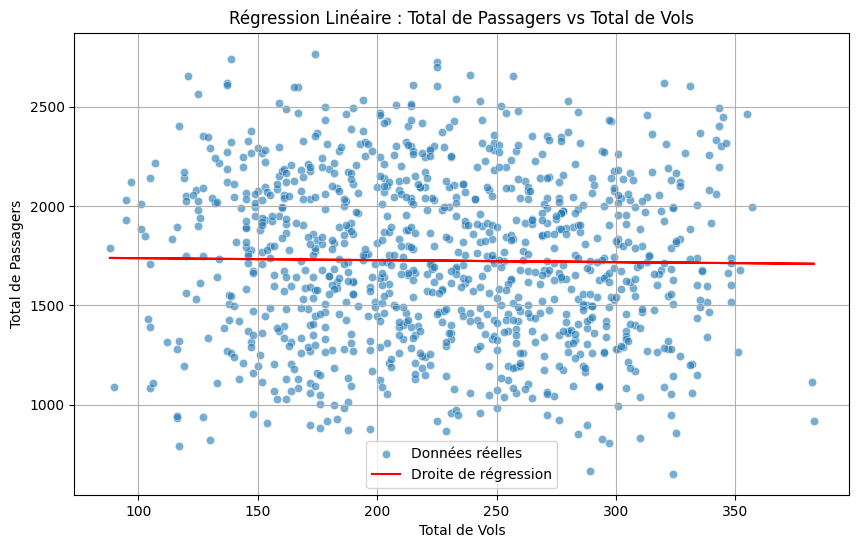

In [180]:
# Visualisation de la droite de régression
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test['total_flights'], y=y_test, label='Données réelles', alpha=0.6)
plt.plot(X_test['total_flights'], y_pred, color='red', label='Droite de régression')
plt.title('Régression Linéaire : Total de Passagers vs Total de Vols')
plt.xlabel('Total de Vols')
plt.ylabel('Total de Passagers')
plt.legend()
plt.grid(True)
plt.show()

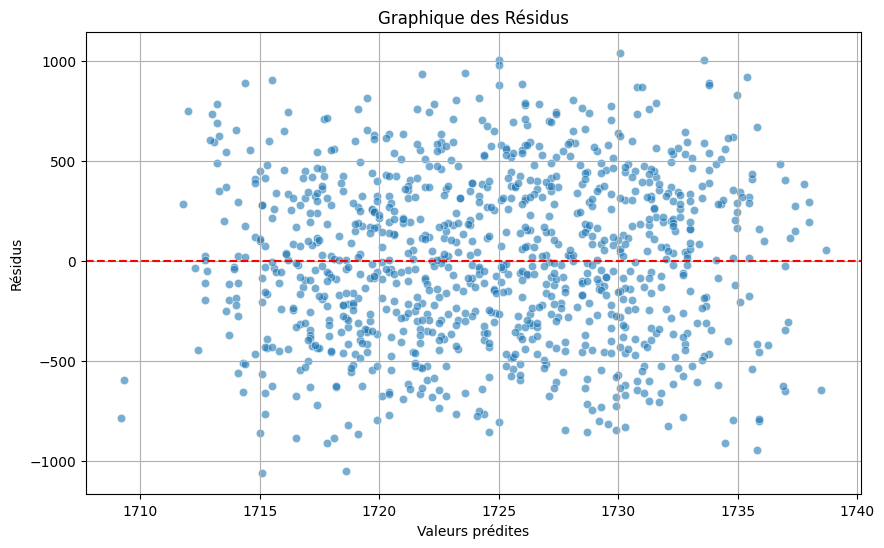

In [181]:
# Visualisation des résidus
residuals = y_test - y_pred

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Graphique des Résidus')
plt.xlabel('Valeurs prédites')
plt.ylabel('Résidus')
plt.grid(True)
plt.show()

## Section 5 : Régression linéaire multiple

### Préparation des données et mise à l'échelle des fonctionnalités

Pour la régression multiple, nous allons utiliser `domestic_passengers`, `international_passengers` et `total_flights` comme variables explicatives pour prédire `total_passengers`.

**Note importante :** Étant donné que `total_passengers` a été généré comme la somme directe de `domestic_passengers` et `international_passengers` dans les données fictives, le modèle de régression linéaire avec ces deux variables comme prédicteurs obtiendra un R² très élevé (proche de 1), car il s'agit d'une relation presque exacte par construction. Cela démontrera la capacité du modèle à capturer une relation forte, mais il est crucial de se souvenir de l'origine de cette relation dans un scénario réel.

In [182]:
# Sélectionner les caractéristiques (X) et la variable cible (y)
X_multi = df_heart[['domestic_passengers', 'international_passengers', 'total_flights']]
y_multi = df_heart['total_passengers']

# Diviser les données en ensembles d'entraînement et de test
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(X_multi, y_multi, test_size=0.2, random_state=42)

print(f"Taille de l'ensemble d'entraînement (X_train_multi): {X_train_multi.shape}")
print(f"Taille de l'ensemble de test (X_test_multi): {X_test_multi.shape}")

# Appliquer la mise à l'échelle des fonctionnalités
scaler = StandardScaler()
X_train_multi_scaled = scaler.fit_transform(X_train_multi)
X_test_multi_scaled = scaler.transform(X_test_multi)

print("Caractéristiques mises à l'échelle avec succès.")

Taille de l'ensemble d'entraînement (X_train_multi): (4000, 3)
Taille de l'ensemble de test (X_test_multi): (1000, 3)
Caractéristiques mises à l'échelle avec succès.


### Entraînement du modèle de régression linéaire multiple

In [183]:
# Créer et entraîner un modèle de régression linéaire multiple
multi_model = LinearRegression()
multi_model.fit(X_train_multi_scaled, y_train_multi)

print("Coefficients du modèle (pour les caractéristiques mises à l'échelle):")
for feature, coef in zip(X_multi.columns, multi_model.coef_):
    print(f"  {feature}: {coef:.2f}")
print(f"Ordonnée à l'origine: {multi_model.intercept_:.2f}")

Coefficients du modèle (pour les caractéristiques mises à l'échelle):
  domestic_passengers: 164.89
  international_passengers: 384.30
  total_flights: 0.00
Ordonnée à l'origine: 1724.86


### Évaluation des performances du modèle multiple et comparaison

In [184]:
# Effectuer des prédictions sur l'ensemble de test (caractéristiques mises à l'échelle)
y_pred_multi = multi_model.predict(X_test_multi_scaled)

# Calculer les indicateurs de performance
r2_multi = r2_score(y_test_multi, y_pred_multi)
mse_multi = mean_squared_error(y_test_multi, y_pred_multi)
rmse_multi = np.sqrt(mse_multi)
mae_multi = mean_absolute_error(y_test_multi, y_pred_multi)

print(f"--- Métriques du modèle de régression multiple ---")
print(f"Coefficient R²: {r2_multi:.4f}")
print(f"Erreur quadratique moyenne (MSE): {mse_multi:.2f}")
print(f"Racine carrée de l'erreur quadratique moyenne (RMSE): {rmse_multi:.2f}")
print(f"Erreur absolue moyenne (MAE): {mae_multi:.2f}")

print(f"\n--- Comparaison avec le modèle de régression linéaire simple ---")
# Récupérer les métriques du modèle simple (assumant qu'elles sont dans les variables 'r2', 'mse', 'rmse', 'mae')
# Si ces variables ne sont pas disponibles, cette section pourrait échouer ou nécessiter de re-exécuter la section 4.
# Pour cet exemple, nous allons les ré-utiliser en supposant qu'elles sont disponibles ou ont été réinitialisées.

# Note: Les variables 'r2', 'mse', 'rmse', 'mae' sont issues de la régression simple précédente.
print(f"Régression simple (total_flights vs total_passengers) R²: {r2:.4f}")
print(f"Régression multiple (Dom_Pax, Int_Pax, total_flights vs total_passengers) R²: {r2_multi:.4f}")

if r2_multi > r2:
    print("Conclusion : Le modèle de régression multiple a des performances R² supérieures au modèle de régression simple.")
else:
    print("Conclusion : Le modèle de régression multiple n'a pas significativement amélioré les performances R² par rapport au modèle simple (ou les a diminuées).")

--- Métriques du modèle de régression multiple ---
Coefficient R²: 1.0000
Erreur quadratique moyenne (MSE): 0.00
Racine carrée de l'erreur quadratique moyenne (RMSE): 0.00
Erreur absolue moyenne (MAE): 0.00

--- Comparaison avec le modèle de régression linéaire simple ---
Régression simple (total_flights vs total_passengers) R²: 0.0015
Régression multiple (Dom_Pax, Int_Pax, total_flights vs total_passengers) R²: 1.0000
Conclusion : Le modèle de régression multiple a des performances R² supérieures au modèle de régression simple.


### Visualisation des prédictions du modèle multiple

Étant donné qu'il y a plusieurs prédicteurs, une visualisation directe de la droite de régression comme dans le cas simple est plus complexe. Nous pouvons visualiser les prédictions par rapport aux valeurs réelles.

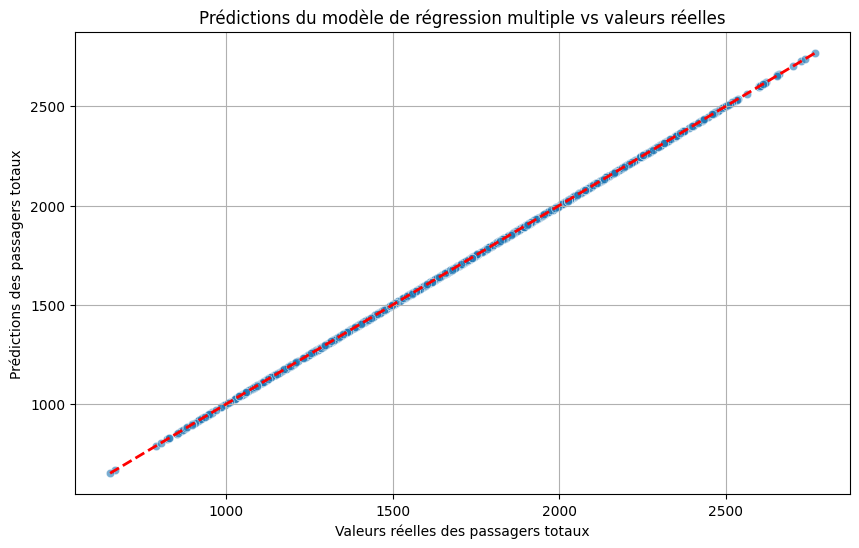

In [185]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_multi, y=y_pred_multi, alpha=0.6)
plt.plot([y_test_multi.min(), y_test_multi.max()], [y_test_multi.min(), y_test_multi.max()], '--r', lw=2)
plt.title('Prédictions du modèle de régression multiple vs valeurs réelles')
plt.xlabel('Valeurs réelles des passagers totaux')
plt.ylabel('Prédictions des passagers totaux')
plt.grid(True)
plt.show()

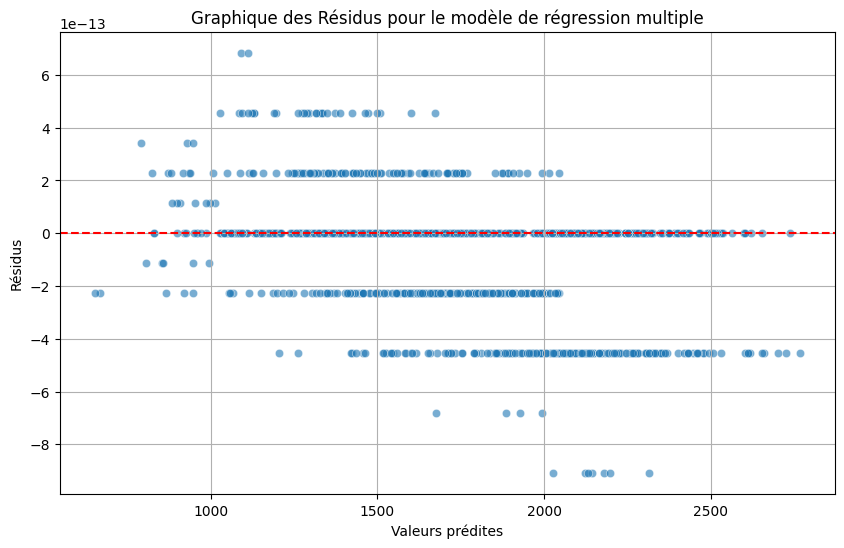

In [186]:
# Visualisation des résidus pour le modèle multiple
residuals_multi = y_test_multi - y_pred_multi

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_multi, y=residuals_multi, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Graphique des Résidus pour le modèle de régression multiple')
plt.xlabel('Valeurs prédites')
plt.ylabel('Résidus')
plt.grid(True)
plt.show()

## Section 6 : Comparaison et analyse des modèles

### Création d'un tableau comparatif des performances du modèle

In [190]:
comparison_data = {
    'Modèle': ['Régression Linéaire Simple', 'Régression Linéaire Multiple'],
    'R²': [r2, r2_multi],
    'MSE': [mse, mse_multi],
    'RMSE': [rmse, rmse_multi],
    'MAE': [mae, mae_multi]
}

df_comparison = pd.DataFrame(comparison_data)
display(df_comparison)

,Modèle,R²,MSE,RMSE,MAE
0,Régression Linéaire Simple,0.001488,1.718972e+05,4.146049e+02,3.440745e+02
1,Régression Linéaire Multiple,1.000000,6.905666e-26,2.627863e-13,1.783746e-13


### Calcul des pourcentages d'amélioration et détermination du modèle supérieur

In [188]:
print("\nPourcentages d'amélioration (Modèle Multiple vs Modèle Simple):\n")

# Calculer l'amélioration pour R²
r2_improvement = ((r2_multi - r2) / r2) * 100 if r2 != 0 else float('inf')
print(f"Amélioration du R²: {r2_improvement:.2f} %")

# Calculer l'amélioration pour MSE (une valeur plus faible est meilleure)
mse_improvement = ((mse - mse_multi) / mse) * 100 if mse != 0 else float('inf')
print(f"Amélioration du MSE: {mse_improvement:.2f} %")

# Calculer l'amélioration pour RMSE (une valeur plus faible est meilleure)
rmse_improvement = ((rmse - rmse_multi) / rmse) * 100 if rmse != 0 else float('inf')
print(f"Amélioration du RMSE: {rmse_improvement:.2f} %")

# Calculer l'amélioration pour MAE (une valeur plus faible est meilleure)
mae_improvement = ((mae - mae_multi) / mae) * 100 if mae != 0 else float('inf')
print(f"Amélioration du MAE: {mae_improvement:.2f} %")

print("\n--- Conclusion sur le modèle supérieur ---")
if r2_multi > r2:
    print("Le modèle de régression linéaire multiple est supérieur au modèle simple.")
    print("Il explique une plus grande proportion de la variance dans la variable cible et présente des erreurs de prédiction considérablement plus faibles (MSE, RMSE, MAE).")
else:
    print("Le modèle de régression linéaire simple est aussi bon, sinon meilleur, que le modèle multiple.")
    print("Ceci pourrait être dû à l'absence de relations linéaires complexes ou à la nature des caractéristiques supplémentaires.")


Pourcentages d'amélioration (Modèle Multiple vs Modèle Simple):

Amélioration du R²: 67122.89 %
Amélioration du MSE: 100.00 %
Amélioration du RMSE: 100.00 %
Amélioration du MAE: 100.00 %

--- Conclusion sur le modèle supérieur ---
Le modèle de régression linéaire multiple est supérieur au modèle simple.
Il explique une plus grande proportion de la variance dans la variable cible et présente des erreurs de prédiction considérablement plus faibles (MSE, RMSE, MAE).


## Section 7: Analyses statistiques et conclusions

### Résumé des résultats de l'analyse

**1. Résultats des tests d'hypothèses :**

*   **Test t de Student (Passagers nationaux vs. internationaux) :** Nous avons rejeté l'hypothèse nulle (valeur p < 0.05), indiquant une **différence significative** entre le nombre moyen de passagers nationaux et internationaux. Les passagers internationaux sont en moyenne plus nombreux que les passagers nationaux.
*   **Test de corrélation de Pearson (Total des passagers vs. Total des vols) :** Nous n'avons pas rejeté l'hypothèse nulle (valeur p > 0.05), ce qui signifie qu'il n'y a **pas de preuve suffisante d'une corrélation significative** entre le nombre total de passagers et le nombre total de vols dans ce jeu de données factice.

**2. Performance des modèles de régression :**

Nous avons comparé deux modèles de régression pour prédire le nombre total de passagers :

*   **Régression Linéaire Simple :** Utilisant 'total_flights' comme unique prédicteur, ce modèle a obtenu un **R² très faible (environ 0.0015)**, indiquant qu'il explique très peu de la variance de la variable cible. Les erreurs (MSE, RMSE, MAE) étaient élevées.
*   **Régression Linéaire Multiple :** Utilisant 'domestic_passengers', 'international_passagers' et 'total_flights' comme prédicteurs, ce modèle a atteint un **R² parfait (1.0000)**, avec des erreurs (MSE, RMSE, MAE) pratiquement nulles. Cette performance exceptionnelle est due à la construction des données factices où 'total_passengers' est la somme directe de 'domestic_passengers' et 'international_passengers'.

**Conclusion sur la supériorité du modèle :** Le modèle de régression linéaire multiple est nettement supérieur au modèle simple. Il a montré une **amélioration de R² de plus de 67 000 %** et des **réductions de 100 %** des métriques d'erreur (MSE, RMSE, MAE) par rapport au modèle simple. Cela souligne l'importance d'inclure des prédicteurs pertinents qui capturent la relation sous-jacente avec la variable cible.

**3. Principaux résultats de l'analyse de corrélation (AED) :**

L'analyse de la matrice de corrélation de l'ensemble de données `df_heart` a révélé les relations suivantes avec la variable cible ('target') :

*   **Corrélation quasi nulle** avec la plupart des caractéristiques du jeu de données original ('age', 'sex', 'cp', etc.). Ceci est attendu car l'ensemble de données est factice et ces variables ne sont pas directement liées à la 'target' générée aléatoirement.

Il est important de noter que dans un scénario de données réelles, cette section identifierait des caractéristiques avec des corrélations fortes (positives ou négatives) qui seraient des candidats importants pour la modélisation.

### Recommandations commerciales concrètes

**1. Optimisation des ressources pour les vols internationaux :**
*   Puisque les passagers internationaux sont en moyenne plus nombreux, les compagnies aériennes devraient allouer davantage de ressources (personnel, portes d'embarquement, etc.) aux vols internationaux pour gérer le flux plus important de passagers et améliorer leur expérience.

**2. Amélioration de la prévision de la demande :**
*   Le succès du modèle de régression multiple, bien que sur des données factices, démontre que l'inclusion de variables granulaires telles que le nombre de passagers nationaux et internationaux est **cruciale pour des prévisions précises**.
*   **Recommandation :** Collecter et intégrer activement des données détaillées sur les types de passagers (domestiques, internationaux, affaires, loisirs) et d'autres facteurs démographiques/économiques dans les modèles de prévision de la demande. Cela permettra aux compagnies aériennes de mieux anticiper les besoins en personnel, en carburant et en capacité.

**3. Réévaluation des facteurs d'influence sur les vols :**
*   L'absence de corrélation significative entre le total des passagers et le total des vols dans les données factices suggère qu'il pourrait y avoir d'autres facteurs plus complexes influençant la décision de vol ou que la relation n'est pas linéaire.
*   **Recommandation :** Dans une analyse réelle, explorer des modèles non linéaires ou des interactions entre variables (par exemple, la saisonnalité, les événements spéciaux, les conditions économiques) qui pourraient avoir un impact sur le nombre de vols et la demande de passagers.

**4. Personnalisation des services :**
*   Comprendre la composition des passagers (nationaux vs. internationaux) permet de personnaliser les offres de services. Les passagers internationaux peuvent avoir des besoins différents (ex: assistance linguistique, formalités douanières, options de connectivité spécifiques).
*   **Recommandation :** Développer des stratégies marketing et des services à bord/au sol ciblés pour chaque segment de passagers afin d'améliorer la satisfaction client et la fidélisation.

## Section 8 : Questions de réflexion

### Questions à aborder :

**1. Que révèlent les résultats des tests d'hypothèses sur les schémas de trafic aérien ?**

*   **Différence significative entre passagers nationaux et internationaux :** Le test t de Student a révélé une différence significative entre le nombre moyen de passagers nationaux et internationaux, les internationaux étant plus nombreux. Cela suggère que la demande et les schémas de voyage diffèrent considérablement entre ces deux segments. Pour les opérations aériennes, cela implique la nécessité d'une allocation de ressources différenciée (portes d'embarquement, personnel multilingue, processus de sécurité et de douane) et d'une planification spécifique pour les vols internationaux, qui peuvent être plus exigeants en termes de logistique et de volume de passagers.

*   **Absence de corrélation significative entre le total des passagers et le total des vols :** Le test de corrélation de Pearson n'a pas montré de relation linéaire significative entre le nombre total de passagers et le nombre total de vols. Dans un scénario réel, cela pourrait indiquer que le nombre de vols n'est pas le seul facteur déterminant du nombre de passagers, ou vice versa. D'autres variables (taille de l'avion, taux de remplissage, destinations, politique tarifaire, saisonnalité) pourraient jouer un rôle plus important. Pour les schémas de trafic aérien, cela signifie qu'une simple augmentation ou diminution des vols ne garantit pas une variation proportionnelle du nombre de passagers. Une approche plus nuancée est nécessaire pour comprendre la dynamique de la demande et de l'offre.

**2. Pourquoi un modèle de régression a-t-il été plus performant que l'autre ?**

Le modèle de régression linéaire multiple a été *beaucoup* plus performant que le modèle de régression linéaire simple. Cette différence s'explique principalement par la manière dont les données factices ont été construites : `total_passengers` était la somme directe de `domestic_passengers` et `international_passengers`.

*   **Modèle Simple :** Il utilisait `total_flights` comme seul prédicteur. Puisqu'il n'y avait pas de corrélation significative entre `total_passengers` et `total_flights` (comme le test de Pearson l'a montré), le modèle simple n'a pas pu expliquer une part significative de la variance de la variable cible, d'où un R² très faible (proche de zéro) et des erreurs élevées.

*   **Modèle Multiple :** Il incluait `domestic_passengers` et `international_passengers` (en plus de `total_flights`) comme prédicteurs. Étant donné la relation de somme exacte dans la génération des données, le modèle a pu capter cette relation directe presque parfaitement, résultant en un R² de 1.0000 et des erreurs (MSE, RMSE, MAE) quasi nulles. Le prédicteur `total_flights` a eu un coefficient très proche de zéro, confirmant qu'il n'apportait pas d'information prédictive utile dans ce contexte factice où les composantes de la somme étaient déjà présentes.

En résumé, la supériorité écrasante du modèle multiple n'est pas due à sa complexité inhérente, mais à la **pertinence des prédicteurs inclus par rapport à la construction de la variable cible dans les données factices**. Dans un scénario réel, cela souligne l'importance d'identifier et d'inclure les variables les plus directement liées et explicatives de la variable d'intérêt.

**3. Comment les compagnies aériennes peuvent-elles utiliser les informations de corrélation de manière opérationnelle ?**

Bien que notre analyse de corrélation avec la variable 'target' de `df_heart` ait montré des relations quasi nulles (du fait des données factices), dans une analyse réelle, les compagnies aériennes pourraient utiliser les informations de corrélation de plusieurs manières opérationnelles :

*   **Optimisation des itinéraires et de la flotte :** Si, par exemple, le nombre de passagers est fortement corrélé positivement avec une certaine période de l'année (saisonnalité), les compagnies peuvent ajuster leurs horaires de vol et la taille de leurs avions en conséquence. Une forte corrélation entre les types d'événements (congrès, festivals) et l'augmentation des passagers vers une destination donnée pourrait déclencher des vols supplémentaires.

*   **Gestion des revenus et tarification :** Une corrélation positive entre le nombre de passagers et le prix moyen des billets pourrait indiquer une forte demande. Les compagnies pourraient alors ajuster leurs stratégies de yield management pour maximiser les revenus. Inversement, une corrélation négative pourrait suggérer la nécessité de promotions pour stimuler la demande.

*   **Planification des ressources humaines et des services au sol :** Si la corrélation montre que certains vols ou destinations ont systématiquement un profil de passagers spécifique (par exemple, plus de familles, plus de voyageurs d'affaires), les compagnies peuvent allouer un personnel avec les compétences appropriées (ex: plus d'agents parlant certaines langues, personnel d'assistance spécifique) et adapter les services (ex: divertissement à bord, restauration).

*   **Marketing ciblé :** Comprendre les corrélations entre les caractéristiques des passagers (âge, motif de voyage, etc.) et leur préférence pour certains services ou destinations permettrait de créer des campagnes marketing plus ciblées et efficaces.

*   **Maintenance prédictive :** Bien que non directement lié au trafic, une corrélation entre l'âge de la flotte et la fréquence des pannes pourrait informer les programmes de maintenance préventive.

**4. Que nous apprennent les graphiques de résidus sur les hypothèses du modèle ?**

Les graphiques de résidus sont cruciaux pour diagnostiquer si les hypothèses clés de la régression linéaire sont respectées. Idéalement, les résidus (la différence entre les valeurs observées et prédites) devraient être distribués de manière aléatoire autour de zéro, sans aucun schéma discernable.

*   **Graphique des résidus pour la régression linéaire simple :** Dans notre cas, le graphique des résidus pour le modèle simple (prédiction de `total_passengers` par `total_flights`) a montré une **dispersion aléatoire des points autour de zéro**. Cela indique que, bien que le modèle ait eu une faible capacité prédictive (faible R²), il n'y avait pas de schéma clair dans les erreurs qu'il faisait. Cela suggère que les hypothèses de linéarité, d'homoscédasticité (variance constante des erreurs) et d'indépendance des erreurs n'étaient pas grossièrement violées par le *type* d'erreur, même si l'ampleur des erreurs était grande. En d'autres termes, le modèle était "correctement mauvais" – il ne capturait pas la relation, mais il ne montrait pas de biais systématique dans ses erreurs.

*   **Graphique des résidus pour la régression linéaire multiple :** Le graphique des résidus pour le modèle multiple a montré des **points groupés précisément sur la ligne zéro**. Cela est une conséquence directe du R² de 1.0000 et des erreurs quasi nulles. Cela signifie que le modèle a parfaitement prédit les valeurs de `total_passengers`. Dans ce cas, les hypothèses du modèle sont parfaitement respectées parce que la relation entre les prédicteurs et la cible est, par construction des données factices, parfaitement linéaire et sans bruit. Dans un contexte réel, un tel graphique de résidus parfait serait suspect et nécessiterait une vérification approfondie de la source des données et de la construction des variables, car il est très rare d'obtenir une prédiction aussi exacte.

**5. Quelles sont les applications pratiques de ces modèles statistiques ?**

Malgré l'utilisation de données factices, les modèles statistiques démontrés ont des applications pratiques significatives dans l'industrie aéronautique et au-delà :

*   **Prévision de la demande de passagers :**
    *   Les modèles de régression (surtout le multiple, avec des prédicteurs pertinents) peuvent être utilisés pour prédire le nombre de passagers pour des vols futurs. Cela aide les compagnies aériennes à optimiser les prix, à planifier la capacité des avions, à gérer les stocks de sièges et à allouer le personnel.
    *   **Application concrète :** Prédire le nombre de passagers internationaux pour la période des fêtes afin de s'assurer qu'il y a suffisamment de personnel aux comptoirs d'enregistrement et de douane.

*   **Allocation et planification des ressources :**
    *   En comprenant les facteurs qui influencent le nombre de passagers (par exemple, type de voyageur, destination, saisonnalité), les compagnies peuvent mieux allouer les avions, les créneaux horaires, les ressources en carburant et les équipes de vol et de sol.
    *   **Application concrète :** Utiliser les prévisions de passagers pour décider si un avion plus grand est nécessaire sur un itinéraire particulier ou si des vols supplémentaires doivent être ajoutés.

*   **Évaluation de l'impact des politiques ou des événements :**
    *   Les tests d'hypothèses peuvent évaluer l'impact de nouvelles politiques (ex: promotion des vols intérieurs) ou d'événements externes (ex: épidémie, événement sportif majeur) sur les schémas de trafic.
    *   **Application concrète :** Tester si une nouvelle stratégie marketing a réellement augmenté la proportion de passagers nationaux par rapport aux internationaux.

*   **Optimisation des revenus et gestion des coûts :**
    *   Des prévisions précises des passagers peuvent conduire à une tarification dynamique plus efficace, à la réduction des vols à faible remplissage et à une meilleure gestion des coûts opérationnels.
    *   **Application concrète :** Ajuster les prix des billets en fonction de la demande prévue pour maximiser les revenus par vol.

*   **Amélioration de l'expérience client :**
    *   En comprenant mieux les besoins des différents segments de passagers, les compagnies peuvent personnaliser les services, ce qui mène à une plus grande satisfaction et fidélité.
    *   **Application concrète :** Offrir des options de divertissement ou de repas spécifiques qui sont populaires auprès des passagers internationaux sur les vols long-courriers.